<a href="https://colab.research.google.com/github/wathsan11/ML-grape-berries-hyperspectral-/blob/main/GrapeBerriesHyperspectral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 45

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/grapes.csv", sep=";") # Load the 'grapes.csv' file into a pandas DataFrame, specifying semicolon as the separator
display(df.head())

,Unnamed: 0,Variety,Sugar content (g/l),x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
0,1,SYRAH,144.738,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,...,0.305829,0.312961,0.315948,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379
1,2,SYRAH,163.251,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,...,0.314022,0.315759,0.321164,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064
2,3,SYRAH,178.398,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,...,0.333914,0.339243,0.340825,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477
3,4,SYRAH,193.545,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,...,0.326189,0.329614,0.334720,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181
4,5,SYRAH,156.519,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,...,0.317075,0.322848,0.324559,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115


In [4]:
df.shape

(274, 207)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Columns: 207 entries, Unnamed: 0 to x.1003.5
dtypes: float64(205), int64(1), object(1)
memory usage: 443.2+ KB


In [6]:
variety = df.Variety
sugarContent = df['Sugar content (g/l)']

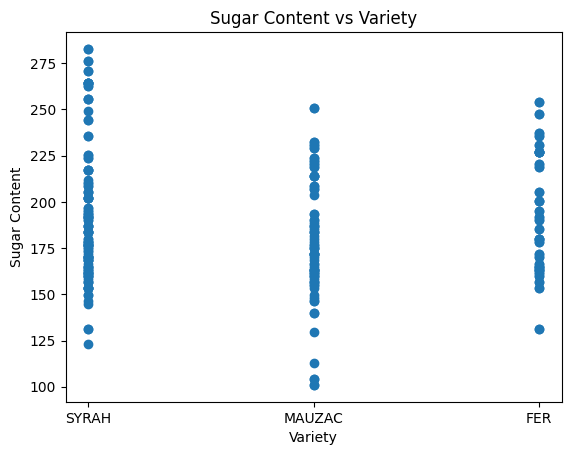

In [7]:
plt.scatter(variety,sugarContent)
plt.ylabel("Sugar Content")
plt.xlabel("Variety")
plt.title("Sugar Content vs Variety")
plt.show()

In [11]:
df_syrah = df[df['Variety'] == 'SYRAH']
display(df_syrah.head())

,Unnamed: 0,Variety,Sugar content (g/l),x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
0,1,SYRAH,144.738,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,...,0.305829,0.312961,0.315948,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379
1,2,SYRAH,163.251,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,...,0.314022,0.315759,0.321164,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064
2,3,SYRAH,178.398,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,...,0.333914,0.339243,0.340825,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477
3,4,SYRAH,193.545,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,...,0.326189,0.329614,0.334720,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181
4,5,SYRAH,156.519,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,...,0.317075,0.322848,0.324559,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115


In [12]:
syrah_sugar_content = df_syrah['Sugar content (g/l)']
syrah_sugar_content.head()

,Sugar content (g/l)
0,144.738
1,163.251
2,178.398
3,193.545
4,156.519


In [16]:
# Select columns that start with 'x.'
syrah_length_columns_df = df_syrah.filter(regex=r'^x\.')
display(syrah_length_columns_df.head())

,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,x.423.29,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
0,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,0.074226,0.070202,0.066113,...,0.305829,0.312961,0.315948,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379
1,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,0.072666,0.068645,0.064228,...,0.314022,0.315759,0.321164,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064
2,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,0.080265,0.076254,0.072553,...,0.333914,0.339243,0.340825,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477
3,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,0.081407,0.077536,0.073961,...,0.326189,0.329614,0.334720,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181
4,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,0.076906,0.072377,0.068974,...,0.317075,0.322848,0.324559,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115


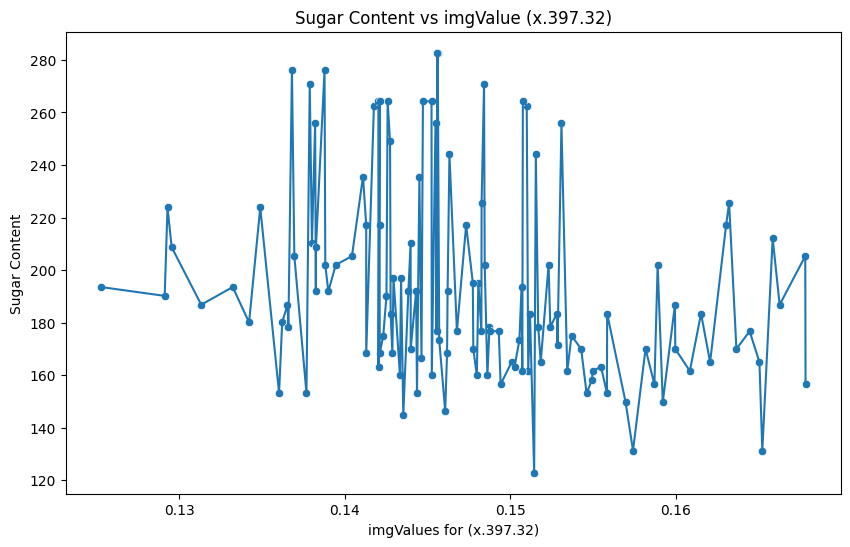

In [51]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="x.397.32", y="Sugar content (g/l)", data=df_syrah)
sns.scatterplot(x="x.397.32", y="Sugar content (g/l)", data=df_syrah)
plt.title("Sugar Content vs imgValue (x.397.32)")
plt.xlabel("imgValues for (x.397.32)")
plt.ylabel("Sugar Content")
plt.show()

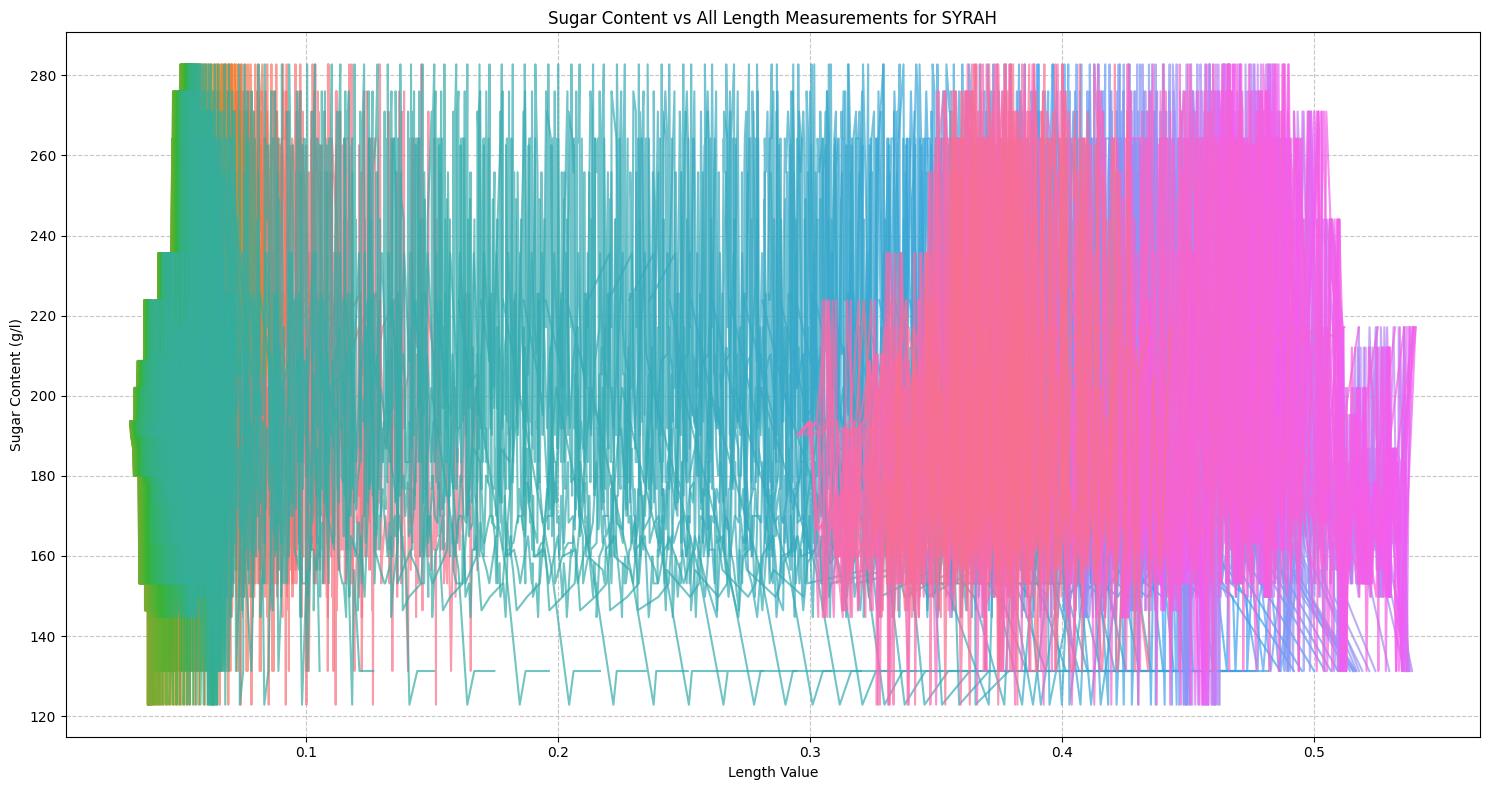

In [43]:
# Select 'Sugar content (g/l)' and all 'x.' columns from df_syrah
plot_df = df_syrah[list(syrah_length_columns_df.columns) + ['Sugar content (g/l)']]

# Reshape the DataFrame using melt
# This transforms the 'x.' columns into rows, making it suitable for plotting multiple lines
melted_df = plot_df.melt(id_vars=['Sugar content (g/l)'],
                         var_name='Length_Feature',
                         value_name='Length_Value')

plt.figure(figsize=(15, 8))
# Use lineplot to visualize the relationship for each length feature
sns.lineplot(data=melted_df, x='Length_Value', y='Sugar content (g/l)', hue='Length_Feature', alpha=0.7, legend=False)

plt.title("Sugar Content vs All Length Measurements for SYRAH")
plt.xlabel("Length Value")
plt.ylabel("Sugar Content (g/l)")

#Place the legend outside the plot area to prevent obscuring data
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels/legend from being cut off
plt.show()

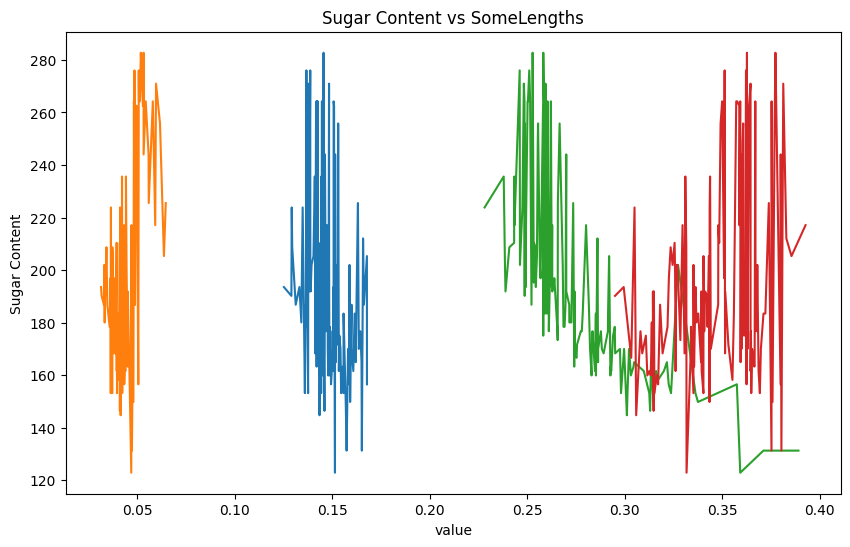

In [49]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="x.397.32", y="Sugar content (g/l)", data=df_syrah)
sns.lineplot(x="x.601.55", y="Sugar content (g/l)", data=df_syrah)
sns.lineplot(x="x.744.53", y="Sugar content (g/l)", data=df_syrah)
sns.lineplot(x="x.975.79", y="Sugar content (g/l)", data=df_syrah)
plt.title("Sugar Content vs SomeLengths")
plt.xlabel("value")
plt.ylabel("Sugar Content")
plt.show()

Data Preprocessing

In [47]:
df = pd.get_dummies(data=df, prefix=['Variety'], columns=['Variety'])
df.head()

,Unnamed: 0,Sugar content (g/l),x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,...,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5,Variety_FER,Variety_MAUZAC,Variety_SYRAH
0,1,144.738,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,0.074226,...,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379,False,False,True
1,2,163.251,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,0.072666,...,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064,False,False,True
2,3,178.398,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,0.080265,...,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477,False,False,True
3,4,193.545,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,0.081407,...,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181,False,False,True
4,5,156.519,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,0.076906,...,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115,False,False,True


In [48]:
x = df.drop(['Sugar content (g/l)', 'Unnamed: 0'], axis=1)
x.head()

,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,x.423.29,...,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5,Variety_FER,Variety_MAUZAC,Variety_SYRAH
0,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,0.074226,0.070202,0.066113,...,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379,False,False,True
1,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,0.072666,0.068645,0.064228,...,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064,False,False,True
2,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,0.080265,0.076254,0.072553,...,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477,False,False,True
3,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,0.081407,0.077536,0.073961,...,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181,False,False,True
4,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,0.076906,0.072377,0.068974,...,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115,False,False,True


In [ ]:
y = df['Sugar content (g/l)']
y.head()

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_,y_train,y_=train_test_split(x,y,test_size=0.4,random_state=RANDOM_STATE)
x_cv,x_test,y_cv,y_test=train_test_split(x_,y_,test_size=0.5,random_state=RANDOM_STATE)
del x_,y_

In [ ]:
x_train.head()

In [ ]:
x_cv.head()

In [ ]:
x_test.head()

In [ ]:
y_train.head()

In [ ]:
y_cv.head()

In [ ]:
y_test.head()